<style>
body { text-autospace: normal; }
h3 { margin-top: 4em !important; }
h4 { margin-top: 2.4em !important; }
h5 { margin-top: 0.3em !important; color: #555 !important; font-weight: 400 !important; }
</style>

### Evo 2 の内部表現をスパースオートエンコーダで読む
##### 第 2 部 — アノテーションによる特徴の選択
***

第 1 部では, 論文が挙げた特徴がアノテーションと重なることを見ました. ただしこれまで扱ってきたのは, 論文があらかじめ特定した特徴に限られます. 32768 本の中から目的に合う特徴を自分で見つける手段が必要です.

論文はこれを contrastive feature search と呼び, Extended Data Fig. 7a に図示しています. どの統計量で順位を付けたかは書かれていないので, ここでは区間ごとの平均活性の差を使います. 論文が挙げている 8 つの特徴がこの計算で何位に来るかを確かめ, 選んだ特徴をトラックに表示するところまでを扱います.

| 節 | 題材 | 内容 |
|---|---|---|
| 02 | Ext Fig. 7a | アノテーションから特徴を選ぶ |
| 03 | — | 選んだ特徴を, まだ見ていない領域に表示する |

### 01. 準備
***

`evo2_sae` を入れます. 特徴を選ぶのに使うのは `class_sums.npz` で, アノテーションが付いた区間ごとに活性を平均し, クラス別に合計したものが入っています. 選んだ特徴を表示するときに, 活性行列から必要な範囲を取り出します.

| ファイル | サイズ | 内容 |
|---|---:|---|
| `class_sums.npz` | 0.7 MB | 全ゲノム 7,279 区間の, クラスごとの平均活性の合計 |
| `ecoli.bed` | 0.2 MB | ゲノム全体の遺伝子座標 |
| `ecoli_values.f16` ほか 2 本 | 2.4 GB | SAE の活性行列 |

In [1]:
%pip install -q git+https://github.com/GenAIBio/evo2-sae-handson

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import evo2_sae
evo2_sae.setup("https://huggingface.co/datasets/suzuki-2001/evo2-sae-handson/resolve/main")

### 02. アノテーションから特徴を選ぶ (Ext Fig. 7a)
***

![contrastive feature search](https://raw.githubusercontent.com/GenAIBio/evo2-sae-handson/main/docs/evo2_ext_fig7a.png)

Brixi et al. *Nature* 2026, Extended Data Fig. 7a より. [CC BY-NC-ND 4.0](https://creativecommons.org/licenses/by-nc-nd/4.0/)

アノテーションの内側と外側で平均活性を取り, その差 $\Delta$ が最も大きい特徴を選びます. 平均を取る単位は塩基ではなく区間です.

区間 $r$ の平均活性を $m_r(f) = \frac{1}{|r|}\sum_{i \in r} z_f(i)$, ある性質を持つ区間の集合を $P$, それ以外の区間の集合を $N$ とすると

$$
f^{*} \;=\; \arg\max_{f}\left[\ \frac{1}{|P|}\sum_{r \in P} m_r(f) \;-\; \frac{1}{|N|}\sum_{r \in N} m_r(f)\ \right]
$$

$m_r(f)$ は, アノテーションが付いた範囲 1 つのなかで活性を平均した値です. rRNA を例にとると, 16S 遺伝子 *rrsA* の 1,542 塩基で f/2812 を平均すると 2.64 になります.

大腸菌ゲノムで rRNA と注釈された区間は 22 あります. この 22 区間で $m_r$ を平均すると 2.18, 残る 7,257 区間では 0.001 で, 差 $\Delta$ は 2.18 です. 同じ計算を 32768 個すべてについて行い, 大きい順に並べます.

区間ごとの平均を足した値と区間数があれば足りるので, 全ゲノムの 7,279 区間ぶんが `class_sums.npz` に入っています. ORF は鎖ごとに分けてあり, 遺伝子間は Extended Data Fig. 7f の記載どおり連続部分を 1 区間にまとめてあります.

In [2]:
sums = np.load(evo2_sae.download("class_sums.npz"))
CLASSES = list(sums["classes"])
total, count = sums["total"], sums["count"]  # (5 クラス, 32768) と (5 クラス,)

grand, regions = total.sum(0), count.sum()

def contrastive(names):
    # 指定したクラスの区間とそれ以外で, 平均活性の差を取る. 返り値は 32768 個ぶん
    i = [CLASSES.index(n) for n in names]
    here, n = total[i].sum(0), count[i].sum()
    return here / n - (grand - here) / (regions - n)

downloading class_sums.npz


論文が Extended Data Fig. 7e,f で挙げている特徴が, この順位のどこに来るかを見ます. ORF と遺伝子間は 2 つずつ挙げられています.

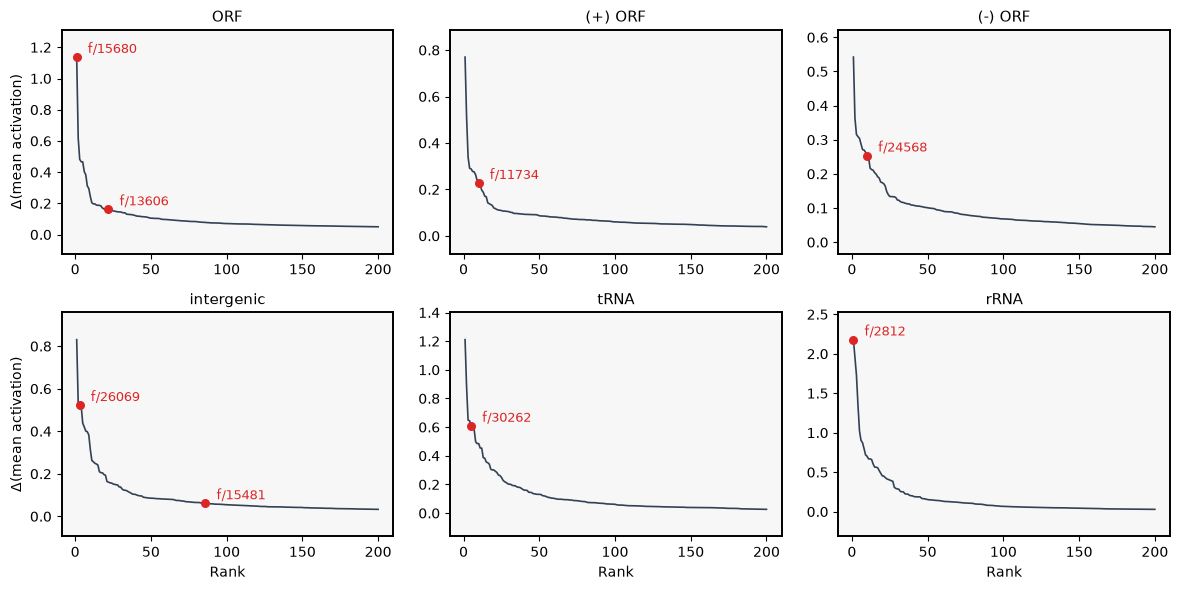

,クラス,区間数,1 位,Δ,論文の特徴と順位
0,ORF,4340,f/15680,1.137,f/15680 (1 位) f/13606 (22 位)
1,(+) ORF,2118,f/15680,0.770,f/11734 (10 位)
2,(-) ORF,2222,f/15680,0.542,f/24568 (10 位)
3,intergenic,2831,f/16174,0.831,f/26069 (3 位) f/15481 (86 位)
4,tRNA,86,f/9811,1.211,f/30262 (5 位)
5,rRNA,22,f/2812,2.179,f/2812 (1 位)


In [3]:
paper = {
    "ORF": (["ORF+", "ORF-"], [15680, 13606]),
    "(+) ORF": (["ORF+"], [11734]),
    "(-) ORF": (["ORF-"], [24568]),
    "intergenic": (["intergenic"], [26069, 15481]),
    "tRNA": (["tRNA"], [30262]),
    "rRNA": (["rRNA"], [2812]),
}

fig, ax = plt.subplots(2, 3, figsize=(12.0, 6.0))
for panel, (name, (names, features)) in zip(ax.ravel(), paper.items()):
    delta = contrastive(names)
    panel.plot(np.arange(1, 201), delta[np.argsort(-delta)][:200], color="#334155", lw=1.2)
    for feature in features:
        rank = int((delta > delta[feature]).sum()) + 1
        panel.scatter([rank], [delta[feature]], color="#dc2626", s=30, zorder=3)
        panel.annotate(
            f"f/{feature}", (rank, delta[feature]), fontsize=9, color="#dc2626",
            textcoords="offset points", xytext=(8, 3),
        )
    panel.margins(y=0.16)
    panel.set_title(name, fontsize=11)
    panel.set_facecolor("#f7f7f7")
    for spine in panel.spines.values():
        spine.set(linewidth=1.4, color="black")
for panel in ax[1]:
    panel.set_xlabel("Rank")
for panel in ax[:, 0]:
    panel.set_ylabel("Δ(mean activation)")
fig.tight_layout()
plt.show()

rows = []
for name, (names, features) in paper.items():
    delta = contrastive(names)
    rows.append({
        "クラス": name,
        "区間数": int(count[[CLASSES.index(n) for n in names]].sum()),
        "1 位": f"f/{int(delta.argmax())}",
        "Δ": round(float(delta.max()), 3),
        "論文の特徴と順位": "  ".join(
            f"f/{f} ({int((delta > delta[f]).sum()) + 1} 位)" for f in features
        ),
    })
pd.DataFrame(rows)

ORF と rRNA では 1 位が論文と一致します. 鎖別の f/11734 と f/24568 はどちらも 10 位, 遺伝子間の f/26069 は 3 位, tRNA の f/30262 は 5 位で, いずれも 32768 個の上位 0.05% に入ります.

上位に来ないのは ORF の f/13606 と遺伝子間の f/15481 で, どちらもクラスに 2 つ挙げられているうちの片方です. f/15481 は論文の AUROC が 0.75 で, 挙げられた 8 つの中で最も低い値です.

f/13606 は論文の AUROC が 0.99 で f/15680 と並びます. それでも Δ が 22 位に留まるのは, ORF 内の平均活性が 0.20 と, f/15680 の 1.24 の 6 分の 1 しかないためです. Δ は平均の差なので, 内と外を同じくらいの比で分けていても, 活性の小さい特徴は上位に来ません. AUROC は順位しか見ないので, この影響を受けません.

### 03. 選んだ特徴を表示する
***

論文の番号ではなく, 上の探索で 1 位になった特徴を *rrnA* オペロンの上に表示します.

rRNA f/2812  tRNA f/9811  intergenic f/16174  ORF f/15680


downloading ecoli.bed


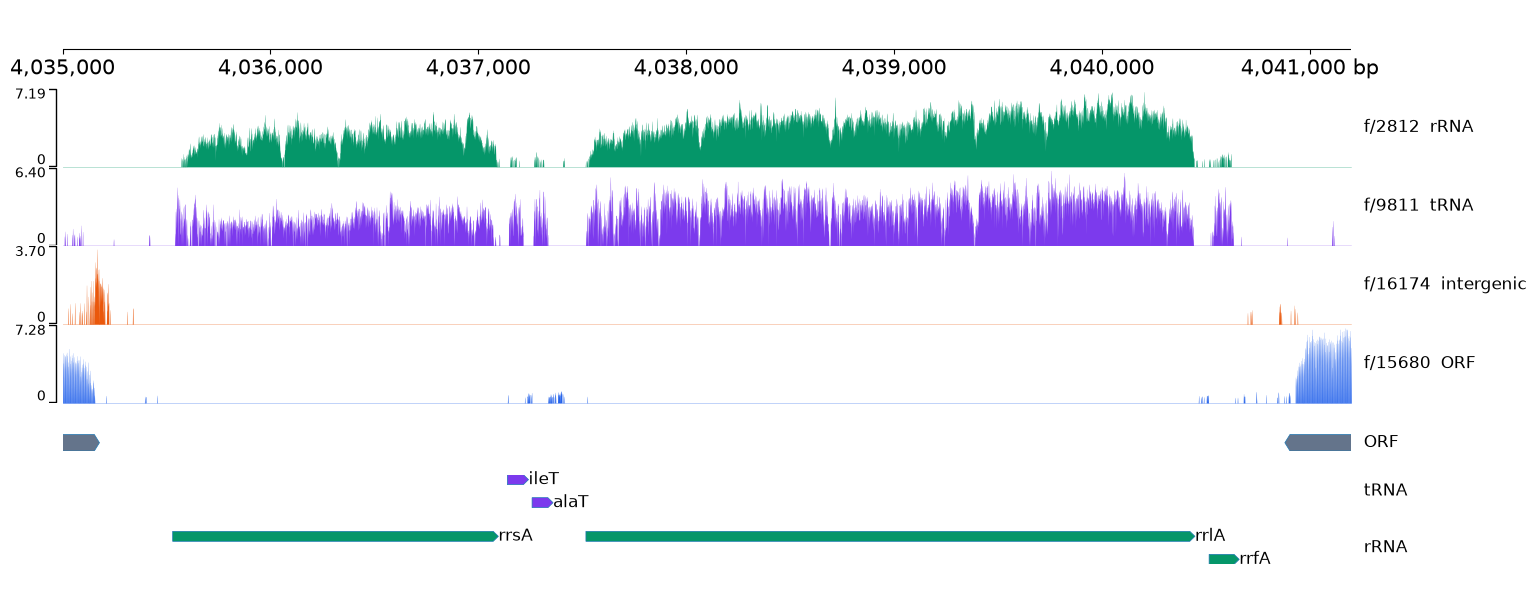

In [4]:
palette = {
    "rRNA": "#059669",
    "tRNA": "#7c3aed",
    "intergenic": "#ea580c",
    "ORF": "#2563eb",
}

best = {name: int(contrastive(paper[name][0]).argmax()) for name in palette}
print("  ".join(f"{name} f/{f}" for name, f in best.items()))

evo2_sae.Region.from_genome("NC_000913.3", 4_035_000, 4_041_200).show(
    [(best[name], colour, f"f/{best[name]}  {name}") for name, colour in palette.items()],
)

rRNA の f/2812 と ORF の f/15680 は 1 位が論文と同じで, 図でも 16S (*rrsA*) と 23S (*rrlA*), および両側の ORF に対応します.

tRNA の 1 位 f/9811 は, スペーサー内の *ileT*・*alaT* ではなくオペロン全体で発火します. 遺伝子間の 1 位 f/16174 は左端の狭い範囲でしか発火しません. どちらも論文が挙げる番号 (f/30262, f/26069) とは別のもので, 1 位が一致したのは rRNA と ORF の 2 つです.

どちらも $\Delta$ では上位に来ています. $\Delta$ が比べるのは区間の内側と外側の平均なので, 区間をはみ出して広く発火する特徴でも, 区間の一部でだけ強く発火する特徴でも, 内側の平均は上がります. 順位が上でも, 発火の範囲が区間と一致するとはかぎりません.

### 参考文献
***

Brixi G, Durrant MG, Ku J, Naghipourfar M, Poli M, Sun G, et al. Genome modelling and design across all domains of life with Evo 2. *Nature* 2026. [doi:10.1038/s41586-026-10176-5](https://doi.org/10.1038/s41586-026-10176-5)

Cunningham H, Ewart A, Riggs L, Huben R, Sharkey L. Sparse autoencoders find highly interpretable features in language models. *arXiv* 2023. [doi:10.48550/arXiv.2309.08600](https://doi.org/10.48550/arXiv.2309.08600)

Xu W, Zhong Q, Lin D, Zuo Y, Dai J, Li G, Cao G. CoolBox: a flexible toolkit for visual analysis of genomics data. *BMC Bioinformatics* 2021. [doi:10.1186/s12859-021-04408-w](https://doi.org/10.1186/s12859-021-04408-w)